In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('tested.csv')
df.head()

Saving tested.csv to tested.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df['Survived'].mean()

np.float64(0.36363636363636365)

<function matplotlib.pyplot.show(close=None, block=None)>

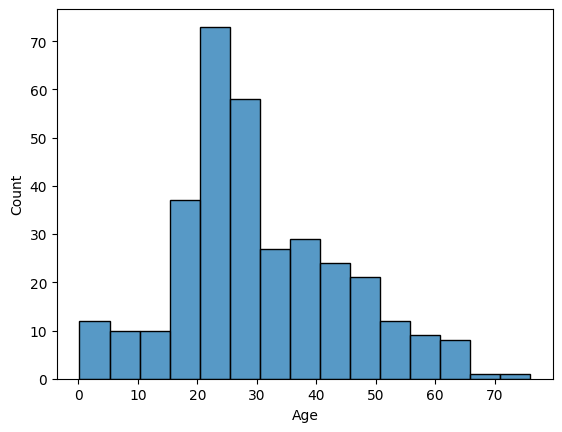

In [ ]:
df['Age'].skew()
sns.histplot(x = "Age", data= df)
plt.show

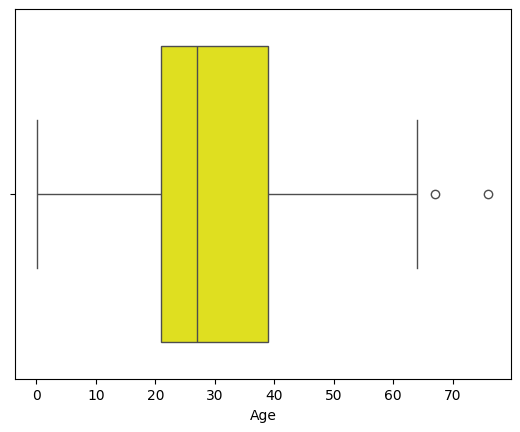

In [ ]:
sns.boxplot(x= "Age", data= df, color="yellow")
plt.show()

**Probabilty**

corelation and covarience

In [ ]:
df.isnull()
df.dropna()
d1 = df.select_dtypes(["float64","int64"]).corr()
d1

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.023245,-0.026751,-0.034102,0.003818,0.043080,0.008211
Survived,-0.023245,1.000000,-0.108615,-0.000013,0.099943,0.159120,0.191514
Pclass,-0.026751,-0.108615,1.000000,-0.492143,0.001087,0.018721,-0.577147
Age,-0.034102,-0.000013,-0.492143,1.000000,-0.091587,-0.061249,0.337932
SibSp,0.003818,0.099943,0.001087,-0.091587,1.000000,0.306895,0.171539
Parch,0.043080,0.159120,0.018721,-0.061249,0.306895,1.000000,0.230046
Fare,0.008211,0.191514,-0.577147,0.337932,0.171539,0.230046,1.000000


In [ ]:
d2 = df.select_dtypes(["float64","int64"]).cov()
d2

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,14595.166667,-1.352518,-2.720624,-59.369047,0.413669,5.107914,55.514238
Survived,-1.352518,0.231960,-0.044037,-0.000088,0.043165,0.075213,5.159417
Pclass,-2.720624,-0.044037,0.708690,-5.906358,0.000820,0.015467,-27.171232
Age,-59.369047,-0.000088,-5.906358,201.106695,-1.135270,-0.704115,291.838610
SibSp,0.413669,0.043165,0.000820,-1.135270,0.804178,0.270100,8.607981
Parch,5.107914,0.075213,0.015467,-0.704115,0.270100,0.963203,12.635175
Fare,55.514238,5.159417,-27.171232,291.838610,8.607981,12.635175,3125.657074


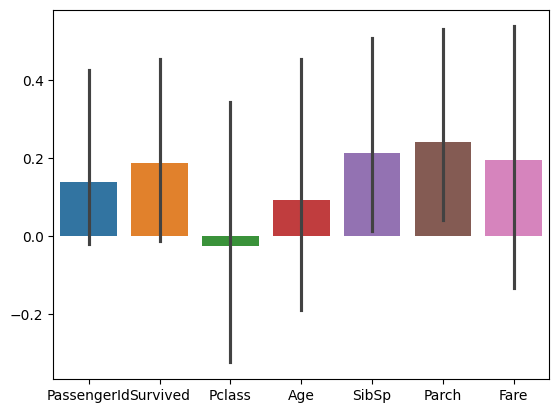

In [ ]:
sns.barplot(d1)
plt.show()

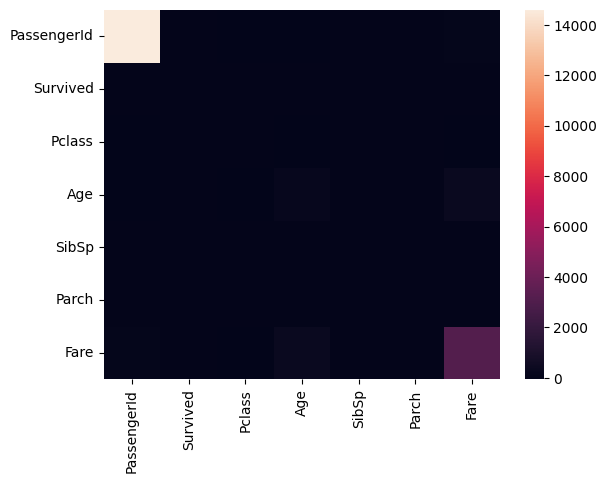

In [ ]:
sns.heatmap(d2)
plt.show()

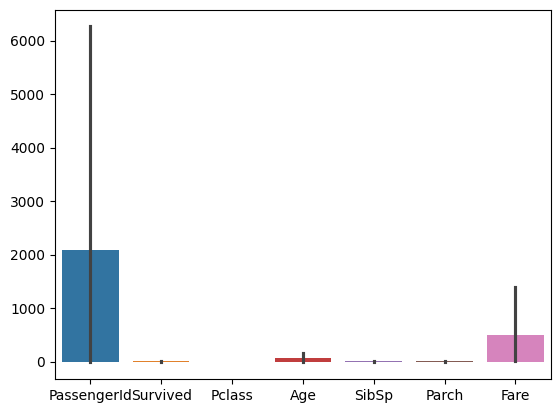

In [ ]:
sns.barplot(d2)
plt.show()

central limit theorem

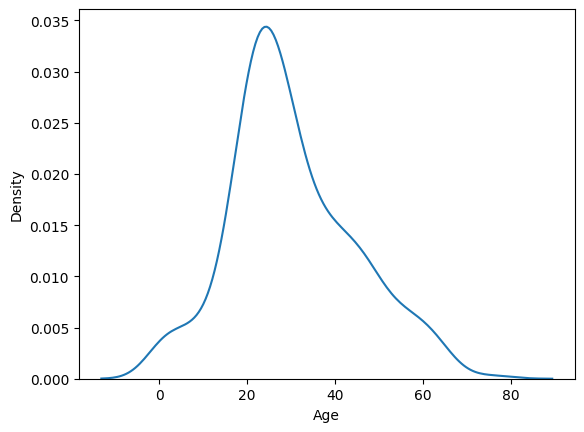

In [ ]:
sns.kdeplot(x = "Age", data= df)
plt.show()

In [ ]:
#total data is 419 so 10% of 419 is 40
sam_mean= df['Age'].sample(40).mean()
print(sam_mean)

32.741379310344826


In [ ]:
new_sam_mean = df['Age'].sample(40).mean()
print(new_sam_mean)
new_sam_mean2 = df['Age'].sample(40).mean()
print(new_sam_mean2)

25.75
31.78272727272727


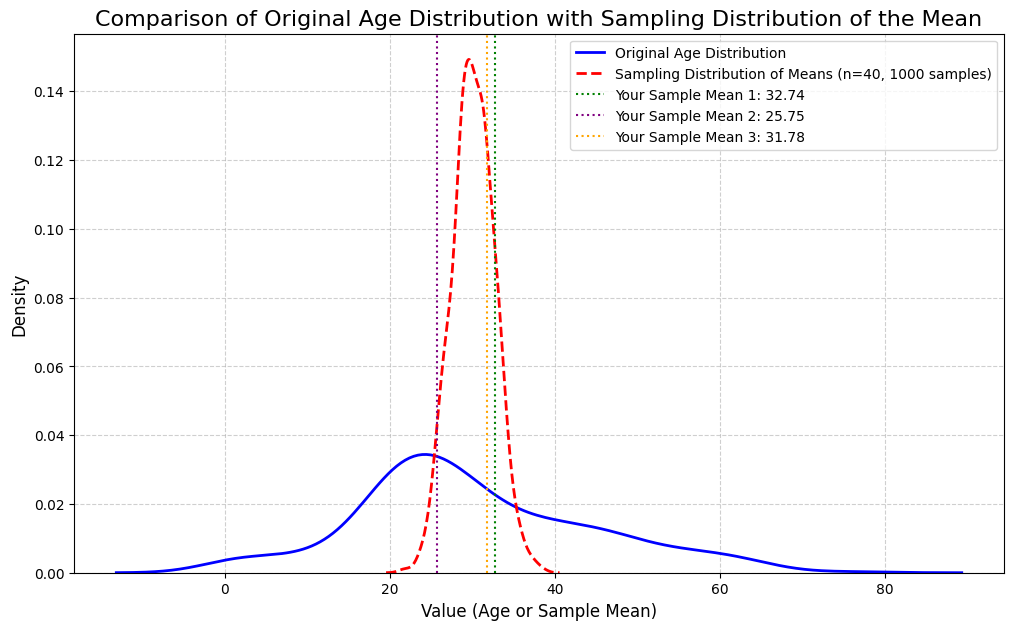

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate many sample means to illustrate the sampling distribution
sample_means_distribution = []
num_simulations = 1000 # Number of times to take a sample
sample_size = 40       # Size of each sample (consistent with your previous samples)

for _ in range(num_simulations):
    # Take a random sample from the 'Age' column and calculate its mean
    sample_means_distribution.append(df['Age'].sample(sample_size, random_state=None, replace=True).mean())

# Create a pandas Series from these sample means for KDE plotting
sample_means_series = pd.Series(sample_means_distribution)

# Create the plot
plt.figure(figsize=(12, 7))

# Plot KDE of the original 'Age' distribution
sns.kdeplot(x=df['Age'], label='Original Age Distribution', color='blue', linewidth=2)

# Plot KDE of the sampling distribution of the means
sns.kdeplot(x=sample_means_series, label=f'Sampling Distribution of Means (n={sample_size}, {num_simulations} samples)', color='red', linestyle='--', linewidth=2)

# Mark the three specific sample means you calculated
# These variables (sam_mean, new_sam_mean, new_sam_mean2) are available in the kernel state.
plt.axvline(x=sam_mean, color='green', linestyle=':', linewidth=1.5, label=f'Your Sample Mean 1: {sam_mean:.2f}')
plt.axvline(x=new_sam_mean, color='purple', linestyle=':', linewidth=1.5, label=f'Your Sample Mean 2: {new_sam_mean:.2f}')
plt.axvline(x=new_sam_mean2, color='orange', linestyle=':', linewidth=1.5, label=f'Your Sample Mean 3: {new_sam_mean2:.2f}')

# Add labels, title, and legend
plt.title('Comparison of Original Age Distribution with Sampling Distribution of the Mean', fontsize=16)
plt.xlabel('Value (Age or Sample Mean)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
mean_of_sample_means = sample_means_series.mean()
print(f"Mean of the sample means distribution: {mean_of_sample_means}")

original_age_mean = df['Age'].mean()
print(f"Mean of the original Age distribution: {original_age_mean}")

Mean of the sample means distribution: 30.112347612069584
Mean of the original Age distribution: 30.272590361445783


As you can see, the mean of the sample means distribution is very close to the mean of the original `Age` distribution, which is a key aspect of the Central Limit Theorem.

This plot helps visualize the **Central Limit Theorem**.

*   The **blue curve** represents the Kernel Density Estimate (KDE) of the `Age` column in your original dataset, showing its shape and density.
*   The **red dashed curve** represents the KDE of the **sampling distribution of the mean**. This was created by taking 1000 different samples of size 40 from the 'Age' column and plotting the distribution of their means. Notice how it tends to be more bell-shaped and narrower than the original distribution, centering around the population mean.
*   The **vertical dotted lines** mark the three specific sample means you calculated (`sam_mean`, `new_sam_mean`, `new_sam_mean2`), showing where they fall within both the original distribution and the sampling distribution.

**hypothesis testing**

In [ ]:
import scipy.stats as st #z test
st.norm.ppf(0.80)

np.float64(0.8416212335729143)

In [ ]:
import scipy.stats as st #t test
t_table=st.t.ppf(0.05,24)
t_table

np.float64(-1.7108820799094282)